## Operadores de busqueda local

Dentro del presente _notebook_ se 

In [1]:
#######################################################
# MODULO DE IMPORTACIONES Y UTILIDADES BASE
# Se reutilizan los módulos ya construidos y validados en Notes_1-NSGA-II
# (codificación de soluciones, Xie-Beni, dominancia de Pareto), en lugar de
# duplicar su lógica, ya que esta iteración se enfoca en los operadores de
# búsqueda local (MOPR y PLS).
#######################################################

############################
# Importaciones
############################
import sys                                                  # Ajuste de sys.path para importar los módulos de Source Code.
from pathlib import Path                                    # Aplicar un formato generalizado de direcciones en el script.

import numpy  as np                                         # Aplicación de operaciones matematicas eficientes.
import matplotlib.pyplot as plt                              # Creación de gráficos.

sys.path.append(str(Path.cwd().parent))                     # Source Code/ (un nivel sobre Investigation_Notes/).

import solution_encoding
from solution_encoding import (
    load_distance_matrix,
    random_medoids_pop,
    build_clusters_population,
    xie_beni,
)
from pareto_sorting import non_dominated_sort, crowding_distance

def _dominates(obj_a, obj_b) -> bool:
    """
    Determina si la solución A domina a la solución B (minimización),
    según la definición (2) del paper:

        A ≺ B  ⟺  ∀t: P_t(A) ≤ P_t(B)  ∧  ∃t: P_t(A) < P_t(B)

    Parámetros
    ----------
    obj_a, obj_b : secuencias de floats (ej. (XBEB, XBBB)).
    """
    not_worse = all(a <= b for a, b in zip(obj_a, obj_b))
    strictly_better = any(a < b for a, b in zip(obj_a, obj_b))
    return not_worse and strictly_better

############################
# Constantes
############################
DE_DIR = Path.cwd().parent.parent / "Datasets" / "Matrices" / "A2_S_DE.csv"
DB_DIR = Path.cwd().parent.parent / "Datasets" / "Matrices" / "A2_S_DB.csv"


def evaluate_objectives(
    medoids: np.ndarray,
    deb_matrix: np.ndarray,
    dbb_matrix: np.ndarray,
) -> tuple[float, float]:
    """
    Evalúa (XBEB, XBBB) para UNA única solución de medoides, envolviendo
    build_clusters_population + xie_beni (pensadas para poblaciones) para
    el caso de un solo individuo, que es lo que requieren MOPR y PLS.

    Nota
    ----
    Siguiendo la misma libertad de eficiencia adoptada en el NSGA-II
    (Notes_1), la asignación de clusters se calcula UNA vez con DEB y se
    reutiliza para ambos índices Xie-Beni, en lugar de recalcularla también
    con DBB como sugiere estrictamente la Tabla 1 del paper. Si se decide
    revertir esta libertad, basta con calcular una segunda asignación con
    build_clusters_population(dbb_matrix, medoids[None, :])[0] y ajustar
    xie_beni para aceptar labels distintas por matriz.
    """
    labels = build_clusters_population(deb_matrix, medoids[None, :])[0]
    return xie_beni(deb_matrix, dbb_matrix, medoids, labels)


def plot_pareto_fronts(
    objectives,
    fronts: list[list[int]],
    title: str = "Frentes de Pareto",
    max_fronts_highlighted: int = 5,
    ax: "plt.Axes | None" = None,
) -> "plt.Axes":
    """
    Versión ligera de la función de graficación de frentes de Pareto usada
    en Notes_1 (XBEB vs XBBB), sin la dependencia de librerías externas de
    diversidad (biocluster), ya que aquí solo se necesita inspección visual
    rápida de los operadores de búsqueda local.
    """
    objectives = np.asarray(objectives, dtype=np.float64)

    own_fig = ax is None
    if own_fig:
        _, ax = plt.subplots(figsize=(7, 5))

    cmap = plt.get_cmap("viridis")
    n_fronts = len(fronts)

    for rank, front in enumerate(fronts):
        pts = objectives[front]
        finite_mask = np.all(np.isfinite(pts), axis=1)
        pts_finite = pts[finite_mask]

        if len(pts_finite) == 0:
            continue

        color = cmap(rank / max(n_fronts - 1, 1))
        label = f"F{rank + 1}" if rank < max_fronts_highlighted else None

        ax.scatter(
            pts_finite[:, 0], pts_finite[:, 1],
            color=color, label=label,
            s=45, edgecolors="black", linewidths=0.5,
            zorder=n_fronts - rank,
        )

        if rank == 0 and len(pts_finite) > 1:
            order = np.argsort(pts_finite[:, 0])
            ax.plot(
                pts_finite[order, 0], pts_finite[order, 1],
                linestyle="--", color=color, alpha=0.6, zorder=0,
            )

    ax.set_xlabel("XBEB (Expresión)")
    ax.set_ylabel("XBBB (Biológico)")
    ax.set_title(title)
    ax.legend(loc="best", fontsize="small", title="Frentes")
    ax.grid(alpha=0.3)
    if own_fig:
        ax.figure.tight_layout()

    return ax

[backend] CuPy detectado → operaciones vectorizadas en GPU.


In [3]:
#######################################################
# MODULO MULTI-OBJECTIVE PATH-RELINKING (MOPR)
#######################################################

def _validate_chromosome(chromosome: np.ndarray, n: int, name: str = "chromosome") -> None:
    """Valida que un cromosoma sea un arreglo 1-D de índices únicos en [0, n)."""
    if chromosome.ndim != 1:
        raise ValueError(f"'{name}' debe ser un arreglo 1-D, se recibió shape {chromosome.shape}.")
    if len(set(chromosome.tolist())) != len(chromosome):
        raise ValueError(f"'{name}' contiene medoides duplicados: {chromosome.tolist()}.")
    if np.any(chromosome < 0) or np.any(chromosome >= n):
        raise ValueError(f"'{name}' contiene índices fuera de rango [0, {n}): {chromosome.tolist()}.")


def _select_best(objectives: list[tuple[float, float]]) -> int:
    """
    Selecciona el mejor índice de un conjunto de candidatas: primero por
    frente de Pareto (F1) y, en caso de empate, por la mayor crowding
    distance — el "best move" de cada paso de la trayectoria (Fig. 2).
    """
    fronts = non_dominated_sort(objectives)
    f1 = fronts[0]

    if len(f1) == 1:
        return f1[0]

    dist = crowding_distance(objectives, f1)
    return max(f1, key=lambda i: dist[i])


def path_relinking(
    start: np.ndarray,
    guide: np.ndarray,
    deb_matrix: np.ndarray,
    dbb_matrix: np.ndarray,
    verbose: bool = False,
) -> list[np.ndarray]:
    """
    Construye la trayectoria PR(start, guide): transforma gradualmente
    `start` en `guide` intercambiando un medoide a la vez, seleccionando en
    cada paso el mejor movimiento mediante dominancia de Pareto + crowding
    distance sobre (XBEB, XBBB).

    Retorna
    -------
    list[np.ndarray] — trayectoria TR(start, guide), desde `start` hasta una
    solución cuyo conjunto de medoides coincide con el de `guide`.
    """
    n = deb_matrix.shape[0]
    _validate_chromosome(start, n, "start")
    _validate_chromosome(guide, n, "guide")
    if start.shape != guide.shape:
        raise ValueError(
            f"'start' y 'guide' deben tener la misma longitud: {start.shape} vs {guide.shape}."
        )

    set_start = set(start.tolist())
    set_guide = set(guide.tolist())

    to_remove = sorted(set_start - set_guide)     # MC1 - MC2
    to_add = sorted(set_guide - set_start)        # MC2 - MC1
    assert len(to_remove) == len(to_add), (
        "El número de medoides a remover y agregar debe coincidir "
        "(ambos cromosomas deben tener la misma longitud k)."
    )

    current = start.copy()
    trajectory = [current.copy()]

    if verbose:
        print(f"[PR] start={start.tolist()}  guide={guide.tolist()}")
        print(f"[PR] to_remove={to_remove}  to_add={to_add}")

    while to_remove:
        candidates, moves = [], []

        # Todas las combinaciones posibles de swap zk -> zl como candidatas.
        for zk in to_remove:
            pos = int(np.where(current == zk)[0][0])
            for zl in to_add:
                candidate = current.copy()
                candidate[pos] = zl
                candidates.append(candidate)
                moves.append((zk, zl))

        objectives = [evaluate_objectives(cand, deb_matrix, dbb_matrix) for cand in candidates]

        best_idx = _select_best(objectives)
        current = candidates[best_idx]
        zk_chosen, zl_chosen = moves[best_idx]

        to_remove.remove(zk_chosen)
        to_add.remove(zl_chosen)
        trajectory.append(current.copy())

        if verbose:
            xbeb, xbbb = objectives[best_idx]
            print(
                f"[PR] swap z_{zk_chosen} → z_{zl_chosen}  → {current.tolist()}  "
                f"(XBEB={xbeb:.6f}, XBBB={xbbb:.6f})"
            )

    return trajectory


def multi_objective_path_relinking(
    C1: np.ndarray,
    C2: np.ndarray,
    deb_matrix: np.ndarray,
    dbb_matrix: np.ndarray,
    verbose: bool = False,
) -> dict:
    """
    Aplica MOPR completo sobre un par de soluciones (C1, C2):

        1. PR(C1, C2) y PR(C2, C1).
        2. Fusiona ambas trayectorias junto con C1 y C2 originales en un
           intermediate pool (IP), eliminando duplicados (mismo conjunto
           de medoides).
        3. Evalúa (XBEB, XBBB) para todo el pool y aplica non-dominated
           sorting; retorna F1 como resultado.

    Retorna
    -------
    dict con:
        "pool", "pool_obj"                       — intermediate pool completo.
        "f1", "f1_obj"                           — frente no dominado del pool.
        "trajectory_C1_to_C2", "trajectory_C2_to_C1" — trayectorias individuales.
    """
    if verbose:
        print("\n[MOPR] Trayectoria PR(C1, C2)")
    traj_c1_c2 = path_relinking(C1, C2, deb_matrix, dbb_matrix, verbose=verbose)

    if verbose:
        print("\n[MOPR] Trayectoria PR(C2, C1)")
    traj_c2_c1 = path_relinking(C2, C1, deb_matrix, dbb_matrix, verbose=verbose)

    # Fusionar y eliminar duplicados por conjunto de medoides.
    all_solutions = traj_c1_c2 + traj_c2_c1
    unique_pool: dict[frozenset, np.ndarray] = {}
    for sol in all_solutions:
        key = frozenset(sol.tolist())
        if key not in unique_pool:
            unique_pool[key] = sol
    pool = np.stack(list(unique_pool.values()))

    pool_obj = [evaluate_objectives(ind, deb_matrix, dbb_matrix) for ind in pool]

    fronts = non_dominated_sort(pool_obj)
    f1_indices = fronts[0]
    f1 = pool[f1_indices]
    f1_obj = [pool_obj[i] for i in f1_indices]

    if verbose:
        print(f"\n[MOPR] Pool fusionado: {pool.shape[0]} soluciones únicas.")
        print(f"[MOPR] Frente no dominado (F1): {len(f1_indices)} soluciones.")

    return {
        "pool": pool, "pool_obj": pool_obj,
        "f1": f1, "f1_obj": f1_obj,
        "trajectory_C1_to_C2": traj_c1_c2, "trajectory_C2_to_C1": traj_c2_c1,
    }

[load] 'A2_S_DE.csv' → matriz 288×288 cargada. Primer gen: 'DDTL', último: 'CDC25A'.
[load] 'A2_S_DB.csv' → matriz 288×288 cargada. Primer gen: 'DDTL', último: 'CDC25A'.
n genes = 288  |  k medoides = 4  |  población de referencia = 6

Frentes de la población de referencia: [3, 1, 2]


[MOPR] Trayectoria PR(C1, C2)
[PR] start=[210, 103, 23, 207]  guide=[92, 220, 279, 166]
[PR] to_remove=[23, 103, 207, 210]  to_add=[92, 166, 220, 279]
[PR] swap z_103 → z_279  → [210, 279, 23, 207]  (XBEB=0.562553, XBBB=3.562059)
[PR] swap z_23 → z_166  → [210, 279, 166, 207]  (XBEB=0.631720, XBBB=3.407662)
[PR] swap z_207 → z_92  → [210, 279, 166, 92]  (XBEB=1.147159, XBBB=1.549763)
[PR] swap z_210 → z_220  → [220, 279, 166, 92]  (XBEB=1.806090, XBBB=1.258873)

[MOPR] Trayectoria PR(C2, C1)
[PR] start=[92, 220, 279, 166]  guide=[210, 103, 23, 207]
[PR] to_remove=[92, 166, 220, 279]  to_add=[23, 103, 207, 210]
[PR] swap z_166 → z_103  → [92, 220, 279, 103]  (XBEB=0.907425, XBBB=1.000675)
[PR] swap z_92 →

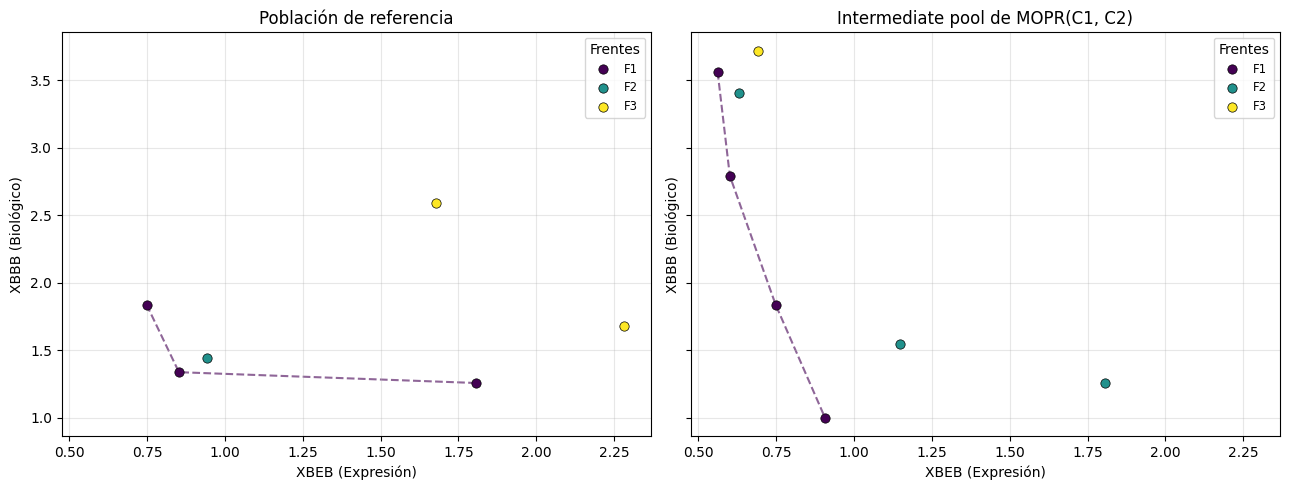

In [5]:
##################################
# Bloque de ejecución: MOPR sobre un par del frente de Pareto
##################################
K        = 4       # número de clusters (medoides por individuo)
POP_SIZE = 6        # población pequeña, solo para ilustrar el operador
SEED     = None       # semilla para reproducibilidad

# ── 1. Carga de matrices DEB/DBB y población de referencia ─────────────────
deb_matrix, gene_names = load_distance_matrix(DE_DIR)
dbb_matrix, _          = load_distance_matrix(DB_DIR)
n = deb_matrix.shape[0]

population = random_medoids_pop(n=n, k=K, pop_size=POP_SIZE, seed=SEED)
objectives = np.array([evaluate_objectives(ind, deb_matrix, dbb_matrix) for ind in population])
fronts = non_dominated_sort(objectives)

# ── 2. Selección de C1, C2 desde el frente no dominado (F1) ────────────────
f1_idx = fronts[0]
if len(f1_idx) >= 2:
    C1, C2 = population[f1_idx[0]], population[f1_idx[1]]
else:
    C1, C2 = population[0], population[1]

##################################
# Resultados por pantalla
##################################
print(f"n genes = {n}  |  k medoides = {K}  |  población de referencia = {POP_SIZE}\n")
print(f"Frentes de la población de referencia: {[len(f) for f in fronts]}\n")

result = multi_objective_path_relinking(C1, C2, deb_matrix, dbb_matrix, verbose=True)

print(f"\n── Frente F1 resultante de MOPR({C1.tolist()}, {C2.tolist()}) ──")
for sol, (xbeb, xbbb) in zip(result["f1"], result["f1_obj"]):
    genes = [gene_names[i] for i in sol]
    print(f"  {genes}  → XBEB={xbeb:.6f}, XBBB={xbbb:.6f}")

# ── Visualización: población de referencia vs. pool/F1 de MOPR ─────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
plot_pareto_fronts(objectives, fronts, title="Población de referencia", ax=axes[0])

pool_fronts = non_dominated_sort(result["pool_obj"])
plot_pareto_fronts(np.asarray(result["pool_obj"]), pool_fronts,
                    title="Intermediate pool de MOPR(C1, C2)", ax=axes[1])
fig.tight_layout()
plt.show()

In [6]:
#######################################################
# MODULO PARETO LOCAL SEARCH (PLS)
#######################################################

def generate_neighborhood(
    C: np.ndarray,
    n: int,
    rng: np.random.Generator,
) -> tuple[list[np.ndarray], int, int]:
    """
    Genera el vecindario N(C) de una solución, reemplazando un medoide
    elegido al azar por cada elemento del dataset aún no presente en C.

    Retorna
    -------
    tuple con:
        neighbors : list[np.ndarray] — |N(C)| = n - k vecinos.
        pos       : int — posición del cromosoma modificada.
        zk        : int — medoide original en esa posición.
    """
    k = len(C)
    pos = int(rng.integers(0, k))
    zk = int(C[pos])

    used = set(C.tolist())
    candidates_z = [z for z in range(n) if z not in used]

    neighbors = []
    for zl in candidates_z:
        neighbor = C.copy()
        neighbor[pos] = zl
        neighbors.append(neighbor)

    return neighbors, pos, zk


def pareto_local_search(
    initial_population: np.ndarray,
    deb_matrix: np.ndarray,
    dbb_matrix: np.ndarray,
    max_iterations: int | None = 200,
    seed: int | None = None,
    verbose: bool = False,
) -> tuple[np.ndarray, list[tuple[float, float]]]:
    """
    Aplica Pareto Local Search (PLS) sobre una población inicial de
    soluciones no dominadas A0 (idealmente el frente F1 de una etapa
    previa, ej. la salida de multi_objective_path_relinking()).

    Mantiene un pool de soluciones (indexado por su conjunto de medoides
    para evitar duplicados) y explora vecindarios hasta que no queden
    soluciones sin explorar, o hasta alcanzar `max_iterations`.

    Retorna
    -------
    tuple (population, objectives) — población final A y sus objetivos
    (XBEB, XBBB), en el mismo orden.
    """
    rng = np.random.default_rng(seed)
    n = deb_matrix.shape[0]

    # Pool: frozenset(medoides) → {"solution", "objectives", "explored"}
    pool: dict[frozenset, dict] = {}
    for sol in initial_population:
        key = frozenset(sol.tolist())
        if key not in pool:
            obj = evaluate_objectives(sol, deb_matrix, dbb_matrix)
            pool[key] = {"solution": sol.copy(), "objectives": obj, "explored": False}

    if verbose:
        print(f"[PLS] Población inicial A0: {len(pool)} soluciones únicas.")

    iteration = 0
    while True:
        unexplored_keys = [key for key, entry in pool.items() if not entry["explored"]]

        if not unexplored_keys:
            if verbose:
                print(f"[PLS] A0 vacía tras {iteration} iteraciones. Población final |A|={len(pool)}.")
            break

        if max_iterations is not None and iteration >= max_iterations:
            if verbose:
                print(f"[PLS] Límite de iteraciones alcanzado ({max_iterations}). "
                      f"Quedan {len(unexplored_keys)} soluciones sin explorar. |A|={len(pool)}.")
            break

        iteration += 1

        # ── 1. Selección ────────────────────────────────────────────────────
        c_key = unexplored_keys[int(rng.integers(0, len(unexplored_keys)))]
        C = pool[c_key]["solution"]
        C_obj = pool[c_key]["objectives"]

        # ── 2. Exploración de vecindad ──────────────────────────────────────
        neighbors, pos, zk = generate_neighborhood(C, n, rng)

        if verbose:
            print(f"[PLS] it={iteration:>4}  C={C.tolist()}  "
                  f"(XBEB={C_obj[0]:.4f}, XBBB={C_obj[1]:.4f})  "
                  f"reemplazando posición {pos} (z_{zk}), |N(C)|={len(neighbors)}")

        # ── 3. Criterio de aceptación (dominancia) ──────────────────────────
        for neighbor in neighbors:
            neighbor_key = frozenset(neighbor.tolist())
            neighbor_obj = evaluate_objectives(neighbor, deb_matrix, dbb_matrix)

            # Si C NO domina a C' (C ⋠ C'), se acepta C' en el pool.
            if not _dominates(C_obj, neighbor_obj):
                if neighbor_key not in pool:
                    pool[neighbor_key] = {
                        "solution": neighbor, "objectives": neighbor_obj, "explored": False,
                    }
                # Eliminar del pool soluciones dominadas por C' (puede incluir a C).
                dominated_keys = [
                    key for key, entry in pool.items()
                    if key != neighbor_key and _dominates(neighbor_obj, entry["objectives"])
                ]
                for key in dominated_keys:
                    del pool[key]

        # Marcar C como explorada (pudo haber sido eliminada si quedó
        # dominada por uno de sus propios vecinos).
        if c_key in pool:
            pool[c_key]["explored"] = True

    population = np.stack([entry["solution"] for entry in pool.values()])
    objectives = [entry["objectives"] for entry in pool.values()]

    return population, objectives

Población de entrada a PLS (F1 de MOPR): 4 soluciones.
Población final de PLS                 : 35 soluciones (tras 60 iteraciones máx).



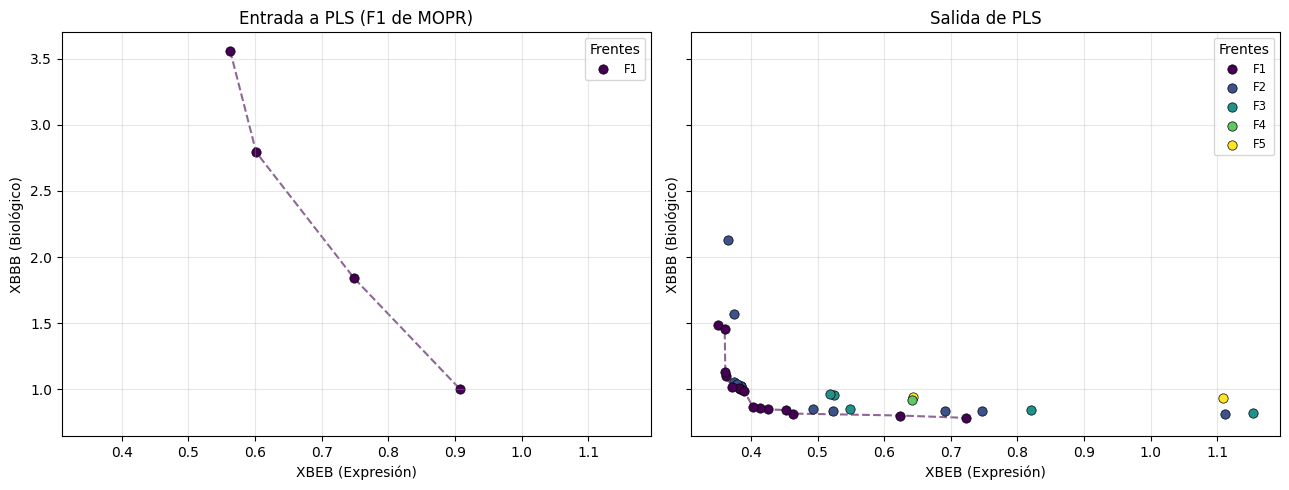

── Frente F1 tras PLS ──
  ['RNASEH2A', 'TMEM62', 'CASQ2', 'CHRM1']  → XBEB=0.623172, XBBB=0.800467
  ['CHRM1', 'TYMS', 'GLT8D2', 'LY86']  → XBEB=0.425932, XBBB=0.847225
  ['SLC6A4', 'TYMS', 'GLT8D2', 'LY86']  → XBEB=0.413222, XBBB=0.860113
  ['JRKL', 'MVB12B', 'TACC3', 'LY86']  → XBEB=0.350131, XBBB=1.488497
  ['JRKL', 'MVB12B', 'BOP1', 'LY86']  → XBEB=0.360721, XBBB=1.457362
  ['E2F3', 'PLCE1', 'GLT8D2', 'LY86']  → XBEB=0.462744, XBBB=0.815172
  ['TET1', 'PLCE1', 'GLT8D2', 'LY86']  → XBEB=0.722117, XBBB=0.782587
  ['JRKL', 'EFR3B', 'GLT8D2', 'FEN1']  → XBEB=0.384129, XBBB=1.000018
  ['JRKL', 'DOCK9', 'GLT8D2', 'FEN1']  → XBEB=0.385346, XBBB=0.997792
  ['JRKL', 'AQP4', 'GLT8D2', 'FEN1']  → XBEB=0.382276, XBBB=1.005981
  ['JRKL', 'LIFR', 'GLT8D2', 'FEN1']  → XBEB=0.372150, XBBB=1.013197
  ['JRKL', 'SLC6A4', 'GLT8D2', 'FEN1']  → XBEB=0.362081, XBBB=1.096176
  ['JRKL', 'MVB12B', 'GLT8D2', 'FEN1']  → XBEB=0.361678, XBBB=1.132807
  ['SLC6A4', 'TYMS', 'DDTL', 'LY86']  → XBEB=0.452971, XBBB=

In [7]:
##################################
# Bloque de ejecución: PLS sobre el F1 resultante de MOPR
##################################
PLS_MAX_ITERATIONS = 60   # limitado para que la demostración sea rápida

pls_pop, pls_obj_list = pareto_local_search(
    initial_population=result["f1"],
    deb_matrix=deb_matrix, dbb_matrix=dbb_matrix,
    max_iterations=PLS_MAX_ITERATIONS, seed=SEED, verbose=False,
)
pls_obj = np.asarray(pls_obj_list, dtype=np.float64)
pls_fronts = non_dominated_sort(pls_obj)

##################################
# Resultados por pantalla
##################################
print(f"Población de entrada a PLS (F1 de MOPR): {len(result['f1'])} soluciones.")
print(f"Población final de PLS                 : {pls_pop.shape[0]} soluciones "
      f"(tras {PLS_MAX_ITERATIONS} iteraciones máx).\n")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
mopr_f1_fronts = [list(range(len(result["f1_obj"])))]
plot_pareto_fronts(np.asarray(result["f1_obj"]), mopr_f1_fronts,
                    title="Entrada a PLS (F1 de MOPR)", ax=axes[0])
plot_pareto_fronts(pls_obj, pls_fronts, title="Salida de PLS", ax=axes[1])
fig.tight_layout()
plt.show()

print("── Frente F1 tras PLS ──")
for idx in pls_fronts[0]:
    sol, (xbeb, xbbb) = pls_pop[idx], pls_obj[idx]
    genes = [gene_names[i] for i in sol]
    print(f"  {genes}  → XBEB={xbeb:.6f}, XBBB={xbbb:.6f}")

In [8]:
#######################################################
# MODULO N-MOLS / L-MOLS (Haidine & Lehnert, 2008; vía Toledo, 2021)
# BETA: pendiente de revisión/ajuste del parámetro `neighborhood` y de
# integración con local_search_step (MOPR + PLS).
#######################################################

def build_neighborhood_matrix(deb_matrix: np.ndarray, dbb_matrix: np.ndarray) -> np.ndarray:
    """
    Matriz de distancia de vecindario M_V (ecuación 3.3, Toledo 2021):
    combina DEB y DBB en una única métrica, usada para decidir si dos genes
    son "vecinos" al generar el vecindario de una solución.

        M_V(gi, gj) = sqrt(DEB(gi, gj)^2 + DBB(gi, gj)^2)
    """
    return np.sqrt(deb_matrix ** 2 + dbb_matrix ** 2)


def generate_neighborhood_mols(
    C: np.ndarray,
    m_v_matrix: np.ndarray,
    neighborhood: float,
) -> list[np.ndarray]:
    """
    Genera Neighborhood(C, M_V) según la ecuación 3.4 (Toledo, 2021): una
    solución vecina difiere de C en EXACTAMENTE un medoide, y la distancia
    M_V entre el medoide reemplazado y su reemplazo debe ser <= `neighborhood`.

    A diferencia de generate_neighborhood() (PLS de Parraga-Alava, que
    reemplaza UNA posición aleatoria por CUALQUIER gen no presente), aquí se
    recorren TODAS las posiciones del cromosoma y solo se aceptan
    reemplazos "cercanos" según M_V — un vecindario acotado y determinista.
    """
    k = len(C)
    used = set(C.tolist())
    neighbors = []

    for pos in range(k):
        zk = int(C[pos])
        close_genes = np.where(m_v_matrix[zk] <= neighborhood)[0]
        for zl in close_genes:
            zl = int(zl)
            if zl == zk or zl in used:
                continue
            neighbor = C.copy()
            neighbor[pos] = zl
            neighbors.append(neighbor)

    return neighbors


def _mols_search(
    population: np.ndarray,
    deb_matrix: np.ndarray,
    dbb_matrix: np.ndarray,
    m_v_matrix: np.ndarray,
    neighborhood: float,
    budget: int,
    accept_fn,
    verbose: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Núcleo compartido de L-MOLS y N-MOLS (Algoritmos 3.6 y 3.7, Toledo 2021):

        Archive = []
        for solution in population:
            for neighbor in Neighborhood(solution, M_V):
                if queda presupuesto and accept_fn(solution, neighbor):
                    Archive = Archive ∪ {neighbor}
        return Archive

    La única diferencia entre ambos algoritmos es `accept_fn`: no-dominación
    para L-MOLS, dominación para N-MOLS. `budget` se consume por cada vecino
    EVALUADO (aceptado o no), igual que el parámetro `evaluations` del paper.
    """
    archive: list[np.ndarray] = []
    archive_obj: list[tuple[float, float]] = []
    seen = {frozenset(sol.tolist()) for sol in population}
    remaining = budget

    for solution in population:
        if remaining <= 0:
            break
        solution_obj = evaluate_objectives(solution, deb_matrix, dbb_matrix)

        for neighbor in generate_neighborhood_mols(solution, m_v_matrix, neighborhood):
            if remaining <= 0:
                break

            key = frozenset(neighbor.tolist())
            if key in seen:
                continue

            neighbor_obj = evaluate_objectives(neighbor, deb_matrix, dbb_matrix)
            remaining -= 1

            if accept_fn(solution_obj, neighbor_obj):
                archive.append(neighbor)
                archive_obj.append(neighbor_obj)
                seen.add(key)

        if verbose:
            print(f"[MOLS] solución {solution.tolist()} → archive acumulado: {len(archive)} "
                  f"(presupuesto restante: {remaining}/{budget})")

    if not archive:
        return np.empty((0, population.shape[1]), dtype=population.dtype), np.empty((0, 2))

    return np.stack(archive), np.asarray(archive_obj, dtype=np.float64)


def l_mols(
    population: np.ndarray,
    deb_matrix: np.ndarray,
    dbb_matrix: np.ndarray,
    m_v_matrix: np.ndarray,
    neighborhood: float,
    budget: int,
    verbose: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Large-Multiobjective Local Search (L-MOLS, Algoritmo 3.6): acepta un
    vecino si la solución actual NO lo domina (no-dominación) — prioriza
    diversidad, acepta cualquier vecino que mejore al menos un objetivo
    aunque empeore otro.
    """
    accept_fn = lambda sol_obj, nb_obj: not _dominates(sol_obj, nb_obj)
    return _mols_search(population, deb_matrix, dbb_matrix, m_v_matrix,
                         neighborhood, budget, accept_fn, verbose=verbose)


def n_mols(
    population: np.ndarray,
    deb_matrix: np.ndarray,
    dbb_matrix: np.ndarray,
    m_v_matrix: np.ndarray,
    neighborhood: float,
    budget: int,
    verbose: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Narrow-Multiobjective Local Search (N-MOLS, Algoritmo 3.7): acepta un
    vecino solo si DOMINA estrictamente a la solución actual (dominación)
    — prioriza convergencia, vecindario de aceptación mucho más angosto.
    """
    accept_fn = lambda sol_obj, nb_obj: _dominates(nb_obj, sol_obj)
    return _mols_search(population, deb_matrix, dbb_matrix, m_v_matrix,
                         neighborhood, budget, accept_fn, verbose=verbose)

M_V → min=0.0681  p5=0.5365  mediana=0.8784  max=1.2952
[MOLS] solución [84, 107, 229, 77] → archive acumulado: 13 (presupuesto restante: 179/200)
[MOLS] solución [238, 211, 145, 91] → archive acumulado: 55 (presupuesto restante: 131/200)
[MOLS] solución [167, 17, 83, 55] → archive acumulado: 142 (presupuesto restante: 35/200)
[MOLS] solución [217, 228, 2, 97] → archive acumulado: 162 (presupuesto restante: 8/200)
[MOLS] solución [76, 39, 186, 100] → archive acumulado: 170 (presupuesto restante: 0/200)
[MOLS] solución [84, 107, 229, 77] → archive acumulado: 3 (presupuesto restante: 179/200)
[MOLS] solución [238, 211, 145, 91] → archive acumulado: 25 (presupuesto restante: 131/200)
[MOLS] solución [167, 17, 83, 55] → archive acumulado: 48 (presupuesto restante: 35/200)
[MOLS] solución [217, 228, 2, 97] → archive acumulado: 51 (presupuesto restante: 8/200)
[MOLS] solución [76, 39, 186, 100] → archive acumulado: 54 (presupuesto restante: 0/200)

L-MOLS → archive de 170 soluciones (presupu

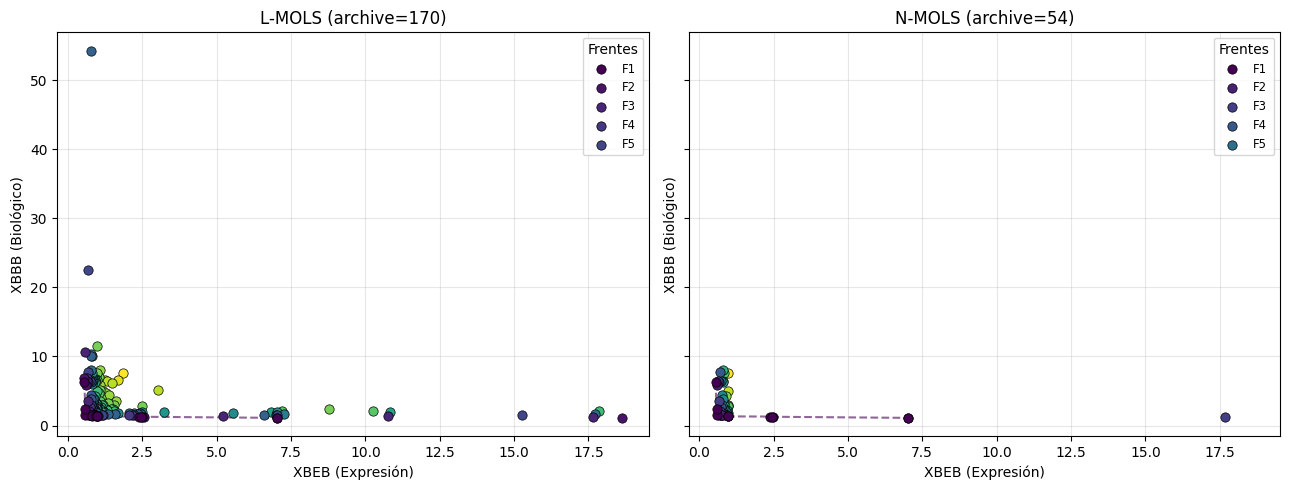

In [9]:
##################################
# Bloque de ejecución: L-MOLS vs N-MOLS sobre una misma población
##################################
m_v_matrix = build_neighborhood_matrix(deb_matrix, dbb_matrix)

# NOTA: el paper acota 'neighborhood' en [0, 1.118] para SUS matrices
# normalizadas; esa cota no es directamente trasladable a las nuestras.
# Como punto de partida se usa el percentil 5 de la distribución de M_V
# (vecindario "angosto" por defecto) — este umbral es el principal
# parámetro a calibrar/revisar en el pulido de este operador.
iu = np.triu_indices_from(m_v_matrix, k=1)
mv_values = m_v_matrix[iu]
NEIGHBORHOOD = float(np.percentile(mv_values, 5))
BUDGET = 200

print(f"M_V → min={mv_values.min():.4f}  p5={NEIGHBORHOOD:.4f}  "
      f"mediana={np.median(mv_values):.4f}  max={mv_values.max():.4f}")

test_pop = random_medoids_pop(n=n, k=K, pop_size=10, seed=SEED)

l_pop, l_obj = l_mols(test_pop, deb_matrix, dbb_matrix, m_v_matrix, NEIGHBORHOOD, BUDGET, verbose=True)
n_pop, n_obj = n_mols(test_pop, deb_matrix, dbb_matrix, m_v_matrix, NEIGHBORHOOD, BUDGET, verbose=True)

print(f"\nL-MOLS → archive de {l_pop.shape[0]} soluciones (presupuesto={BUDGET}).")
print(f"N-MOLS → archive de {n_pop.shape[0]} soluciones (presupuesto={BUDGET}).")

l_fronts = non_dominated_sort(l_obj) if len(l_obj) else [[]]
n_fronts = non_dominated_sort(n_obj) if len(n_obj) else [[]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
plot_pareto_fronts(l_obj, l_fronts, title=f"L-MOLS (archive={l_pop.shape[0]})", ax=axes[0])
plot_pareto_fronts(n_obj, n_fronts, title=f"N-MOLS (archive={n_pop.shape[0]})", ax=axes[1])
fig.tight_layout()
plt.show()